# **Credit Rating**

## Instructions
This template provides a suggested structure for your project

- Problem Statement and Objectives
- Data Loading and Exploration
- Data Preprocessing
- Feature Engineering
- Model Development
- Model Evaluation
- Interpretation and Business Insights
- Conclusions and Future Work

**Remember:**
- Document your thought process with markdown cells
- Comment your code clearly
- Create visualizations to support your insights
- Interpret results in business terms
- Check the evaluation rubric to ensure you meet all criteria

## 1. Data Loading and Exploration

Load the training data and perform initial exploration.

In [12]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data_path = Path("..") / "data" / "corporate_rating.csv"
train_df = pd.read_csv(data_path)

print(f"Dataset shape: {train_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nFirst few rows:")
train_df.head()

Dataset shape: (2029, 31)

Columns: ['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'Sector', 'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']

First few rows:


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [2]:
# Basic information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Rating                              2029 non-null   object 
 1   Name                                2029 non-null   object 
 2   Symbol                              2029 non-null   object 
 3   Rating Agency Name                  2029 non-null   object 
 4   Date                                2029 non-null   object 
 5   Sector                              2029 non-null   object 
 6   currentRatio                        2029 non-null   float64
 7   quickRatio                          2029 non-null   float64
 8   cashRatio                           2029 non-null   float64
 9   daysOfSalesOutstanding              2029 non-null   float64
 10  netProfitMargin                     2029 non-null   float64
 11  pretaxProfitMargin                  2029 no

In [3]:
# Summary statistics
train_df.describe()

,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
count,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,...,2029.000000,2029.000000,2.029000e+03,2.029000e+03,2029.000000,2029.000000,2029.000000,2.029000e+03,2029.000000,2029.000000
mean,3.529607,2.653986,0.667364,333.795606,0.278447,0.431483,0.497968,0.587322,-37.517928,-73.974193,...,0.397572,0.409550,5.094719e+03,4.227549e+03,3.323579,0.437454,48.287985,6.515123e+03,1.447653,38.002718
std,44.052361,32.944817,3.583943,4447.839583,6.064134,8.984982,0.525307,11.224622,1166.172220,2350.275719,...,10.595075,3.796488,1.469156e+05,1.224000e+05,87.529866,8.984299,529.118961,1.775290e+05,19.483294,758.923588
min,-0.932005,-1.893266,-0.192736,-811.845623,-101.845815,-124.343612,-14.800817,-124.343612,-40213.178290,-87162.162160,...,-100.611015,-120.916010,-4.912742e+03,-1.915035e+01,-2555.419643,-124.343612,-3749.921337,-1.195049e+04,-4.461837,-76.662850
25%,1.071930,0.602825,0.130630,22.905093,0.021006,0.025649,0.233127,0.044610,0.019176,0.028112,...,0.146854,0.271478,4.119924e-01,1.566038e+00,2.046822,0.028057,6.238066,2.356735e+00,0.073886,2.205912
50%,1.493338,0.985679,0.297493,42.374120,0.064753,0.084965,0.414774,0.107895,0.045608,0.074421,...,0.300539,0.644529,2.131742e+00,3.686513e+00,2.652456,0.087322,9.274398,4.352584e+00,0.133050,5.759722
75%,2.166891,1.453820,0.624906,59.323563,0.114807,0.144763,0.849693,0.176181,0.077468,0.135036,...,0.370653,0.836949,4.230253e+00,8.086152e+00,3.658331,0.149355,12.911759,7.319759e+00,0.240894,9.480892
max,1725.505005,1139.541703,125.917417,115961.637400,198.517873,309.694856,2.702533,410.182214,0.487826,2.439504,...,429.926282,34.594086,5.753380e+06,4.786803e+06,2562.871795,309.694856,11153.607090,6.439270e+06,688.526591,20314.880400


In [4]:
# Check for missing values
missing_values = train_df.isnull().sum()
missing_pct = (missing_values / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values:")
print(missing_df)

Missing Values:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


## 2. Exploratory Data Analysis (EDA)

Create visualizations to understand the data better.

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


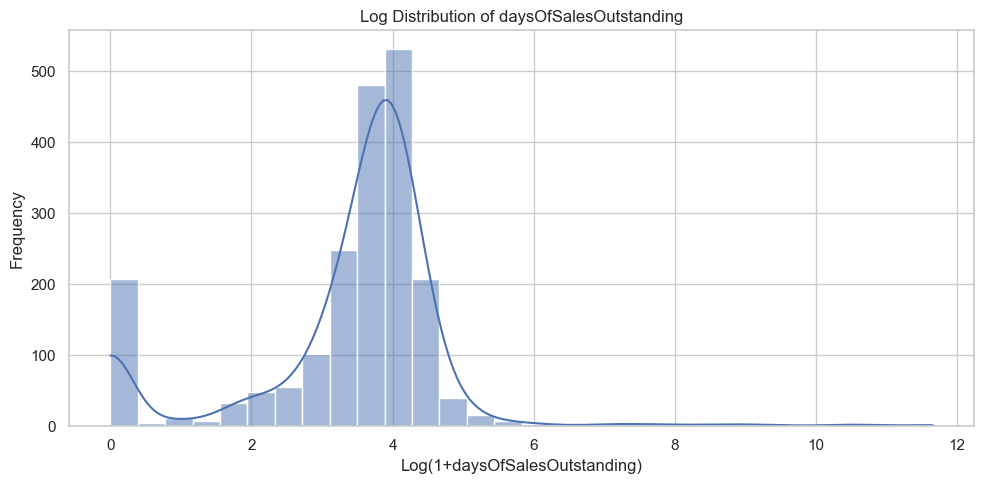

Variabili eliminate:  ['cashRatio', 'daysOfSalesOutstanding', 'pretaxProfitMargin', 'operatingProfitMargin', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio']

Colonne rimaste:  ['currentRatio', 'quickRatio', 'netProfitMargin', 'grossProfitMargin', 'returnOnAssets', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'enterpriseValueMultiple', 'payablesTurnover', 'Rating_encoded']


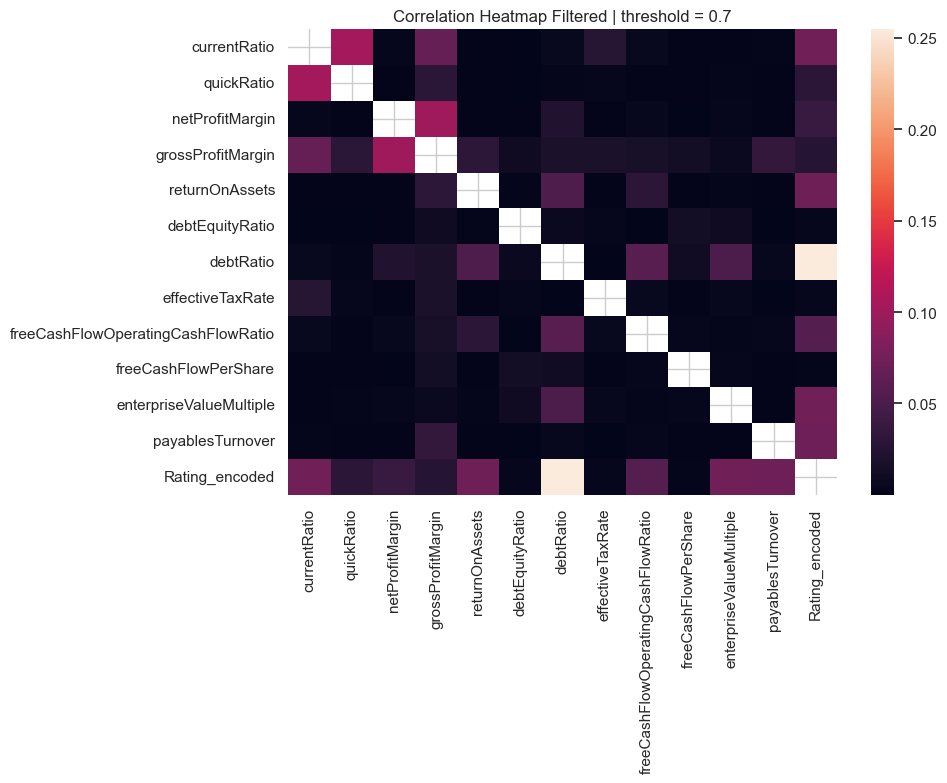

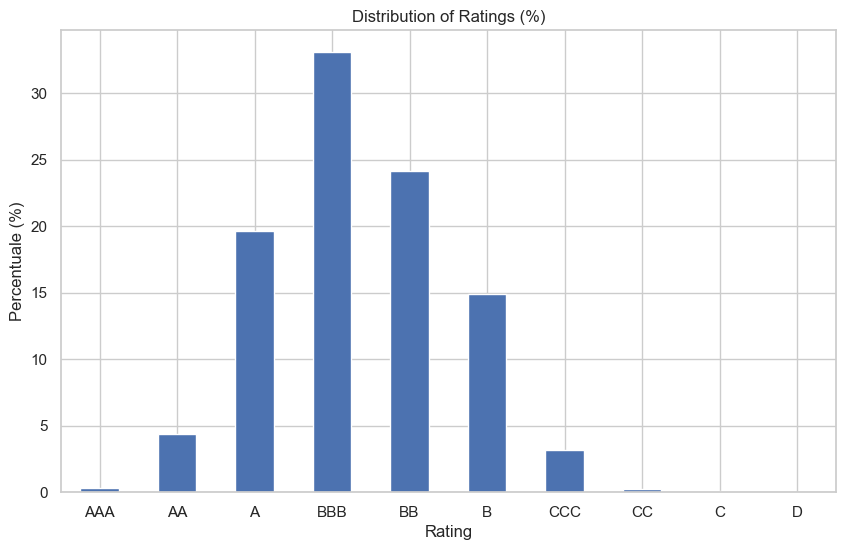

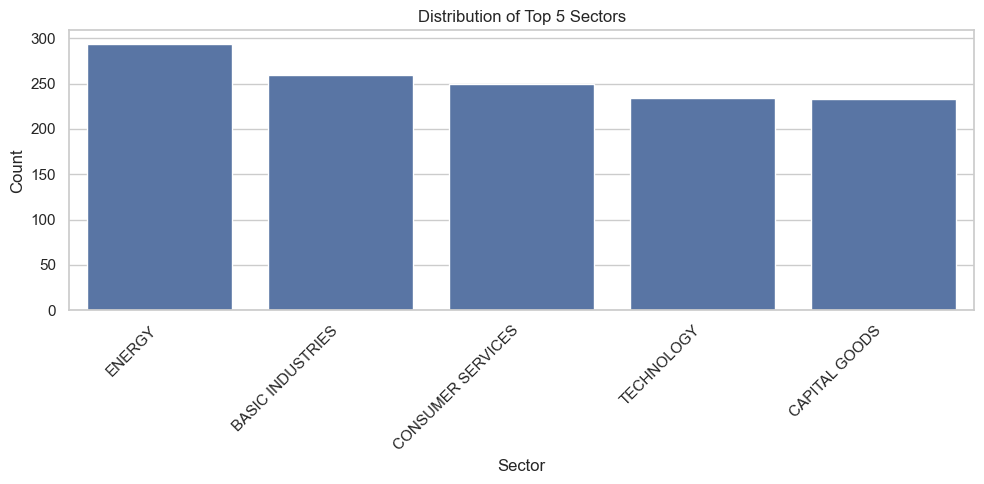

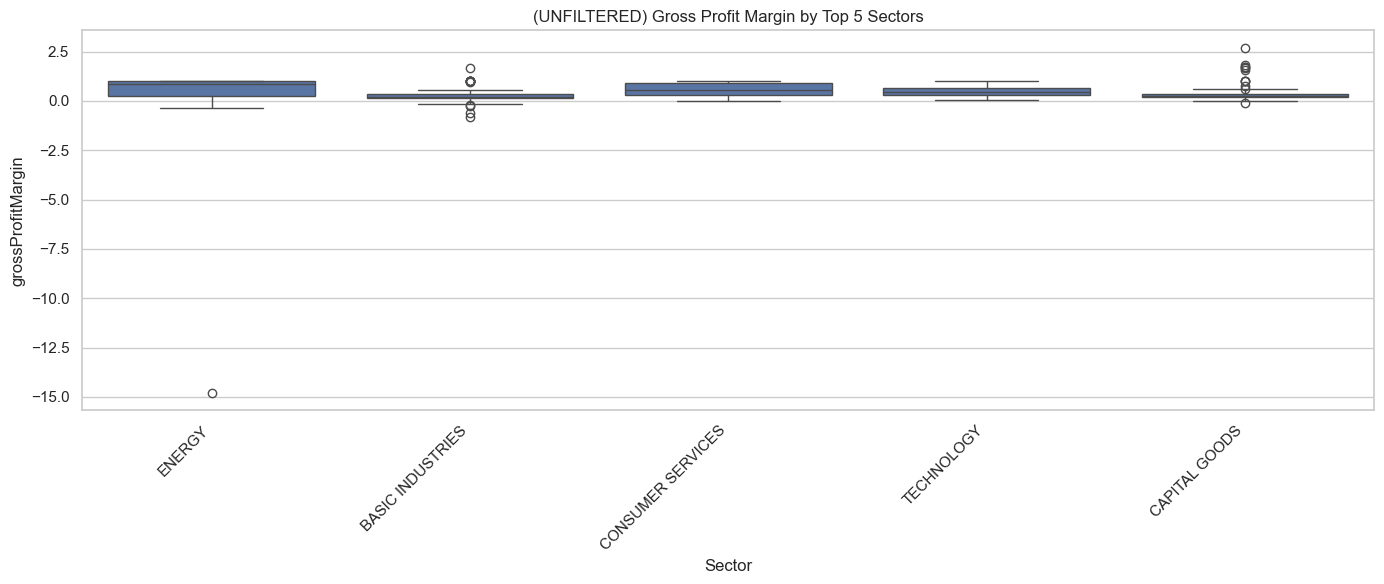

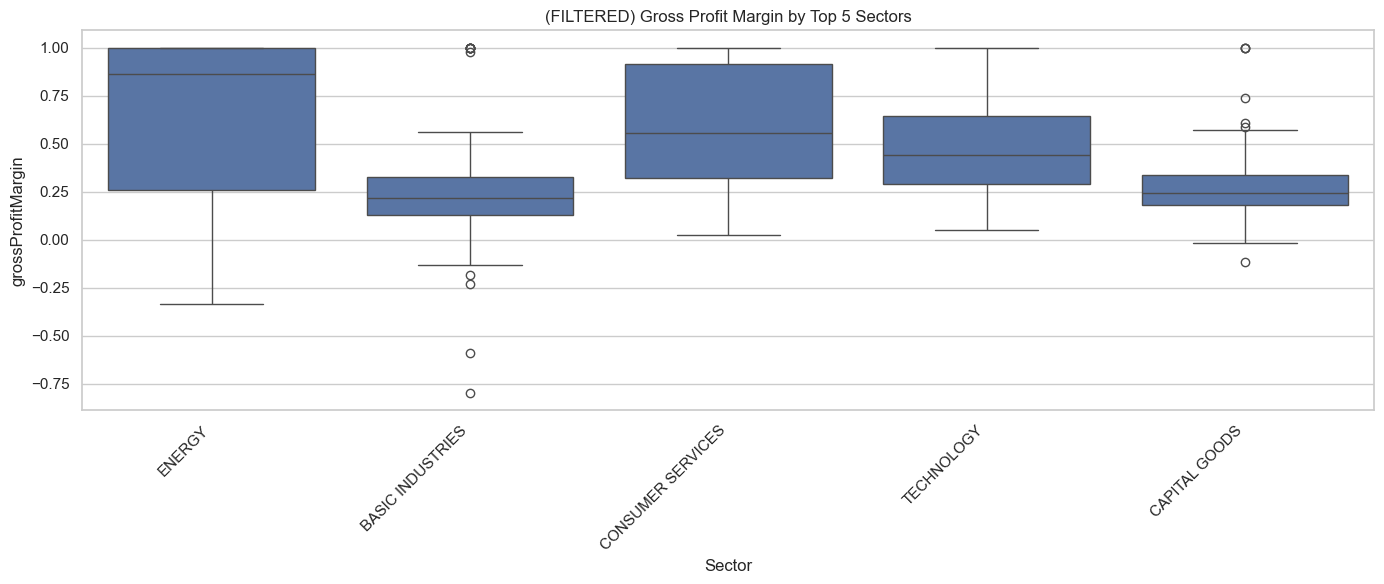

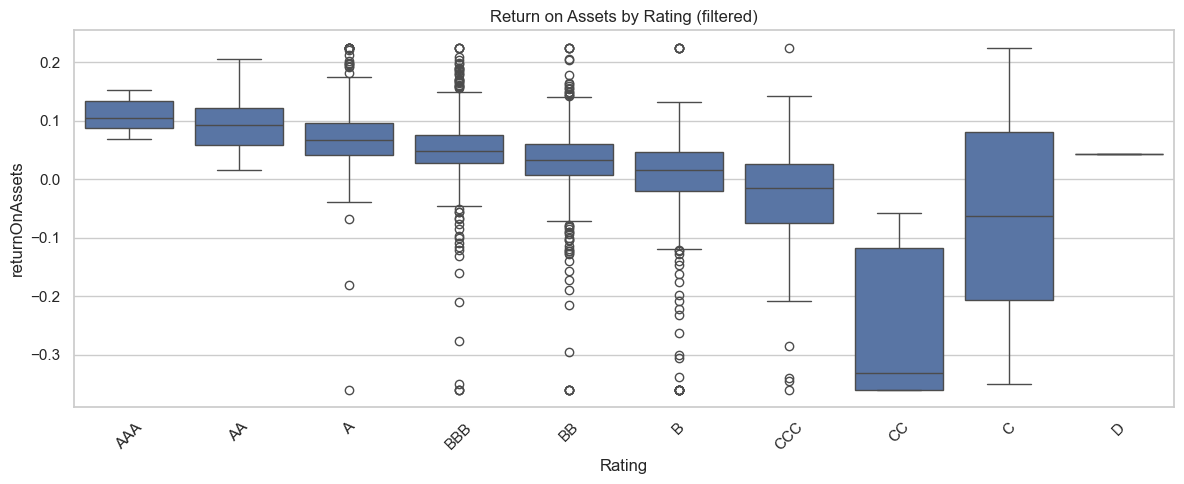

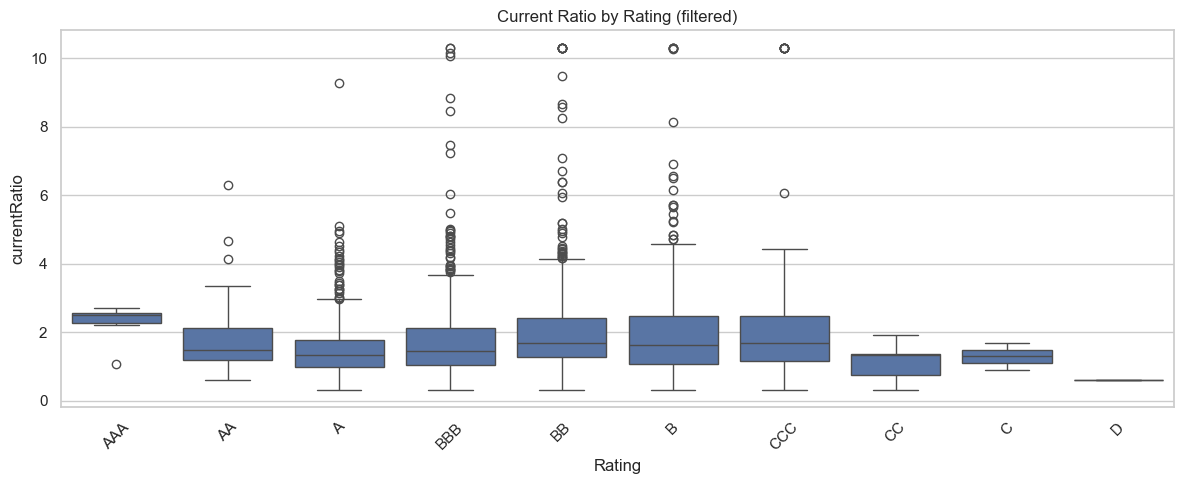

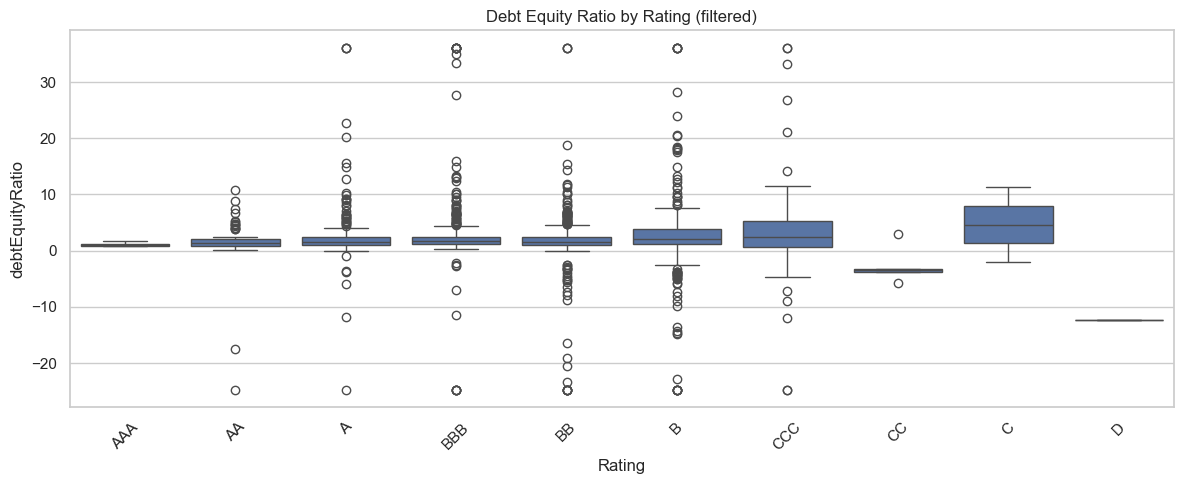

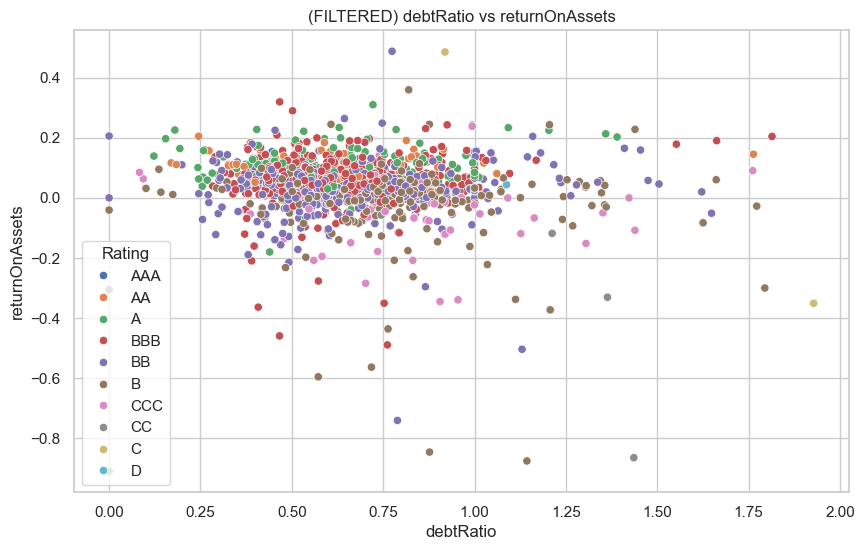

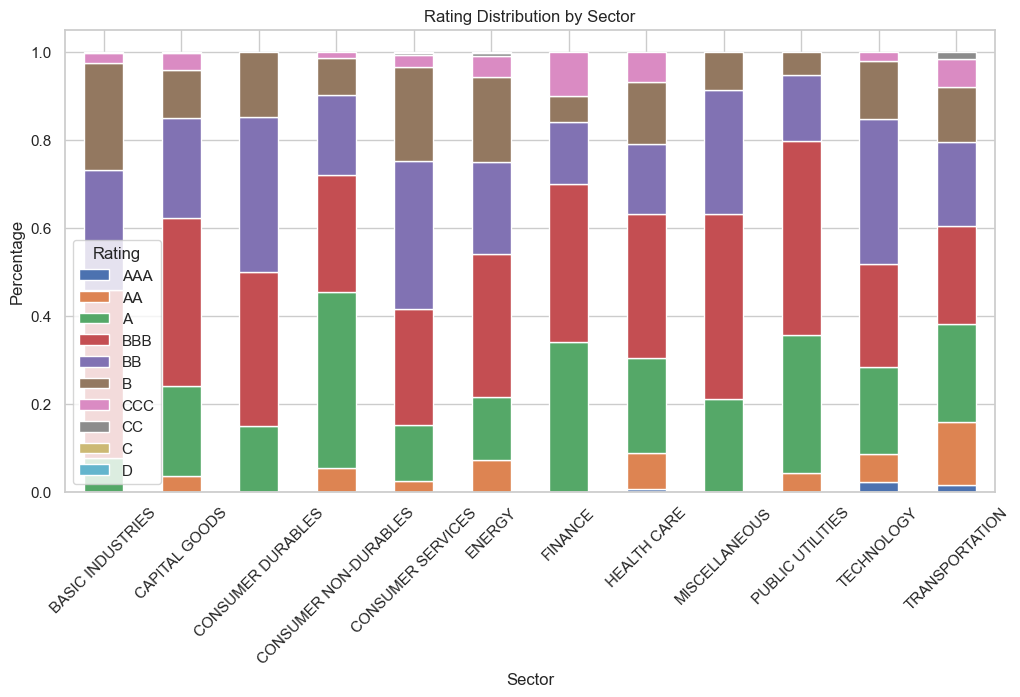

In [ ]:
#CREATING NUMERIC-ONLY DATAFRAME + SETTING GRID CHARACTERISTICS
numeric_df = train_df.select_dtypes(include="number")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
train_df["Rating"] = train_df["Rating"].str.upper().str.strip()
train_df["Sector"] = train_df["Sector"].str.upper().str.strip()


#TAKING SOME COLUMNS AND CONVERTING THEM INTO NUMBERS
numeric_cols = [
    "grossProfitMargin",
    "returnOnAssets",
    "currentRatio",
    "debtEquityRatio"
]
for col in numeric_cols:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")


#LOGARITHMIC DISTRIBUTION PLOT FOR A COLUMN TO SHOW EXTREME OUTLIERS
testCol = "daysOfSalesOutstanding"
dataTest = pd.to_numeric(train_df[testCol], errors="coerce").dropna()
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(dataTest), bins=30, kde=True)
plt.title(f"Log Distribution of {testCol}")
plt.xlabel(f"Log(1+{testCol})")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


#CORRELATION HEATMAP WITHOUT MULTICOLINEARITY CASES
corr = numeric_df.corr().abs()
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]
print("Variabili eliminate: ",to_drop)
filtered_df = numeric_df.drop(columns=to_drop).copy()
print("\nColonne rimaste: ",filtered_df.columns.tolist())
plt.figure(figsize=(10, 8))
corr = filtered_df.corr().abs()
mask = np.eye(corr.shape[0], dtype=bool)
sns.heatmap(corr, mask=mask)
plt.title('Correlation Heatmap Filtered | threshold = 0.7')
plt.tight_layout()
plt.show()


#RATING ENCODING
rating_scale = {
    'AAA': 1,
    'AA': 2,
    'A': 3,
    'BBB': 4,
    'BB': 5,
    'B': 6,
    'CCC': 7,
    'CC': 8,
    'C': 9,
    'D': 10
}
train_df['Rating_encoded'] = train_df['Rating'].map(rating_scale)


#DISTRIBUTION OF RATINGS
order = ['AAA','AA','A','BBB','BB','B','CCC','CC','C','D']
perc = train_df['Rating'].value_counts(normalize=True).reindex(order) * 100
plt.figure()
perc.plot(kind='bar')
plt.ylabel('Percentuale (%)')
plt.title('Distribution of Ratings (%)')
plt.xticks(rotation=0)
plt.show()


#SECTORS DISTRIBUTION
topSectors = train_df["Sector"].value_counts().head(5).index
sector_df = train_df[train_df["Sector"].isin(topSectors)].copy()
plt.figure(figsize=(10, 5))
sns.countplot(data=sector_df, x="Sector", order=topSectors)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Top 5 Sectors")
plt.xlabel("Sector")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


#UNFILTERED AND FILTERED BOXPLOT IN TOP 5 SECTORS
plt.figure(figsize=(14, 6))
sns.boxplot(data=sector_df, x="Sector", y="grossProfitMargin", order=topSectors)
plt.xticks(rotation=45, ha="right")
plt.title("(UNFILTERED) Gross Profit Margin by Top 5 Sectors")
plt.tight_layout()
plt.show()
sector_df_filtered = sector_df[
    (sector_df["grossProfitMargin"] >= -1) &
    (sector_df["grossProfitMargin"] <= 1)
]
plt.figure(figsize=(14, 6))
sns.boxplot(data=sector_df_filtered, x="Sector", y="grossProfitMargin", order=topSectors)
plt.xticks(rotation=45, ha="right")
plt.title("(FILTERED) Gross Profit Margin by Top 5 Sectors")
plt.tight_layout()
plt.show()


#FILTERED BOXPLOTS BY RATING FOR 3 MAIN VARIABLES
def filtered_boxplot(df, column, title):
    temp_df = df.copy()
    lower = temp_df[column].quantile(0.01)
    upper = temp_df[column].quantile(0.99)
    temp_df[column] = temp_df[column].clip(lower, upper)
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=temp_df, x="Rating", y=column, order=order)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
filtered_boxplot(train_df, "returnOnAssets", "Return on Assets by Rating (filtered)")
filtered_boxplot(train_df, "currentRatio", "Current Ratio by Rating (filtered)")
filtered_boxplot(train_df, "debtEquityRatio", "Debt Equity Ratio by Rating (filtered)")


#"DEBT RATIO" - "RETURN ON ASSETS" SCATTERPLOT WITH RATING AS HUE
tempFiltered_df = train_df[
    (train_df['returnOnAssets'] >= -1) &
    (train_df['returnOnAssets'] <= 1)
]
plt.figure()
sns.scatterplot(
    data=tempFiltered_df,
    x='debtRatio',
    y='returnOnAssets',
    hue='Rating',
    hue_order=['AAA','AA','A','BBB','BB','B','CCC','CC','C','D']
)
plt.title('(FILTERED) debtRatio vs returnOnAssets')
plt.show()


#RATING DISTRIBUTION BY SECTOR
rating_sector_pct = pd.crosstab(
    train_df['Sector'],
    train_df['Rating'],
    normalize='index'
).reindex(columns=order)
rating_sector_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.title('Rating Distribution by Sector')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

#### TO-DO: Document your key findings from EDA
- The dataset is imbalanced, with mid-level ratings (BBB) dominating, while extreme ratings (AAA, C, CC) are relatively rare.
- Linear correlations between features are generally weak, relationships may be non-linear.
- The dataset contains significant skewness and extreme outliers, especially in leverage and liquidity ratios.
- Higher rated firms exhibit more stable and less dispersed financial ratios while lower rated firms show greater variability and more extreme values(this may be an indicator for higher financial risk and instability)

## 3. Data Preprocessing

Handle missing values, outliers, and prepare data for modeling.

In [ ]:
# Create a copy for preprocessing
df_processed = train_df.copy()

# TODO: Handle missing values
# Use median imputation for numeric columns because many financial variables
# are skewed and contain extreme values, so the median is more robust than the mean
numeric_cols = df_processed.select_dtypes(include="number").columns

for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# TODO: Handle outliers
# Clip numeric variables at the 1st and 99th percentiles
# This reduces the effect of extreme values without removing observations
for col in numeric_cols:
    lower = df_processed[col].quantile(0.01)
    upper = df_processed[col].quantile(0.99)
    df_processed[col] = df_processed[col].clip(lower, upper)

# TODO: Encode categorical variables
# One-hot encode Sector since it is a nominal categorical feature
df_processed = pd.get_dummies(df_processed, columns=["Sector"], drop_first=True)

print("Preprocessing complete!")

Preprocessing complete!


In [15]:
# Separate features and target
X = df_processed.drop(columns=["Rating"])
y = df_processed["Rating"]

# Train-validation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling
# Use RobustScaler because the dataset contains skewed values and outliers
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Feature scaling complete!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)

ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: ['D']

## 4. Feature Engineering

Create new features based on domain knowledge.

In [ ]:
# TODO: Engineer features
# Ideas:
# - Financial ratios (if not already present)
# - Year-over-year changes (growth rates)
# - Interaction features
# - Altman Z-Score or similar bankruptcy models
# - Sector-relative features (company vs sector average)
# - Temporal features (trends, volatility)

# Example: Year-over-year change
# df_processed = df_processed.sort_values(['company_id', 'fiscal_year'])
# df_processed['roe_yoy_change'] = df_processed.groupby('company_id')['roe'].diff()

print("Feature engineering complete!")
print(f"Total features: {df_processed.shape[1]}")

#### TO-DO: List and explain your engineered features
1. 
2. 
3. 
4. 

## 5. Model Development

Train multiple models and compare performance.

In [ ]:
# Import models
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    f1_score, roc_auc_score, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from xgboost import XGBClassifier, XGBRegressor

# For handling class imbalance (Challenges 1 & 2)
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

print("Model libraries imported!")

In [ ]:
# TODO: Prepare X and y
# feature_cols = [...]  # List your feature columns
# target_col = 'bankruptcy_next_year'  # or 'financial_health_class' or 'revenue_change'

# X_train = df_train[feature_cols]
# y_train = df_train[target_col]
# X_val = df_val[feature_cols]
# y_val = df_val[target_col]

print("Data prepared for modeling!")

### Baseline Model

In [ ]:
# TODO: Train baseline model
# For classification: Logistic Regression
# For regression: Linear Regression

# Example for Challenge 1 (Bankruptcy):
# baseline_model = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced')
# baseline_model.fit(X_train_scaled, y_train)
# y_pred_baseline = baseline_model.predict(X_val_scaled)

# print("Baseline Model Performance:")
# print(classification_report(y_val, y_pred_baseline))
# print(f"F1-Score: {f1_score(y_val, y_pred_baseline):.4f}")

### Advanced Models

In [ ]:
# TODO: Train multiple models
# - Random Forest
# - XGBoost
# - Gradient Boosting
# - etc.

# For classification with imbalance, consider:
# - SMOTE oversampling
# - Class weights
# - Threshold tuning

# Example for Random Forest with SMOTE:
# smote = SMOTE(random_state=RANDOM_STATE)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=10,
#     random_state=RANDOM_STATE
# )
# rf_model.fit(X_train_resampled, y_train_resampled)

print("Advanced models trained!")

In [ ]:
# TODO: Hyperparameter tuning
# Use GridSearchCV or RandomizedSearchCV

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Example:
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 5, 10]
# }

# grid_search = GridSearchCV(
#     RandomForestClassifier(random_state=RANDOM_STATE),
#     param_grid,
#     cv=StratifiedKFold(n_splits=5),
#     scoring='f1',
#     n_jobs=-1
# )
# grid_search.fit(X_train_scaled, y_train)
# best_model = grid_search.best_estimator_

print("Hyperparameter tuning complete!")

## 6. Model Evaluation

Compare models and select the best one.

In [ ]:
# TODO: Create model comparison table
# Compare all models on validation set using appropriate metrics

# For Challenge 1: F1-Score, AUC-ROC, Precision, Recall
# For Challenge 2: Weighted F1, Macro F1, Accuracy, Confusion Matrix
# For Challenge 3: RMSE, MAE, MAPE, R², Directional Accuracy

# Example comparison:
# models_comparison = pd.DataFrame({
#     'Model': ['Baseline', 'Random Forest', 'XGBoost'],
#     'F1-Score': [...],
#     'AUC-ROC': [...],
#     'Precision': [...],
#     'Recall': [...]
# })
# print(models_comparison)

In [ ]:
# TODO: Confusion Matrix (for classification)
# from sklearn.metrics import ConfusionMatrixDisplay

# ConfusionMatrixDisplay.from_estimator(best_model, X_val_scaled, y_val)
# plt.title('Confusion Matrix - Best Model')
# plt.show()

In [ ]:
# TODO: ROC Curve (for binary classification)
# from sklearn.metrics import RocCurveDisplay

# RocCurveDisplay.from_estimator(best_model, X_val_scaled, y_val)
# plt.title('ROC Curve - Best Model')
# plt.show()

#### TODO: Justify your final model choice
- 
- 
- 
- 

## 7. Interpretation and Business Insights

Explain the model and extract business value.

In [ ]:
# TODO: Feature Importance
# For tree-based models, use built-in feature importance
# For other models, consider SHAP values

# Example:
# feature_importance = pd.DataFrame({
#     'feature': feature_cols,
#     'importance': best_model.feature_importances_
# }).sort_values('importance', ascending=False)

# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
# plt.xlabel('Importance')
# plt.title('Top 15 Most Important Features')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

In [ ]:
# TODO: Error Analysis
# - Which cases does the model misclassify/mispredicts?
# - Are there patterns in the errors?
# - How do errors vary by sector, size, region, etc.?

# Example:
# errors_df = df_val.copy()
# errors_df['prediction'] = y_pred
# errors_df['error'] = (errors_df['prediction'] != errors_df[target_col])

# print("Error rate by sector:")
# print(errors_df.groupby('ateco_sector')['error'].mean().sort_values(ascending=False))

#### TO-DO: Translate technical findings into business language

##### **Key Risk Factors** (for bankruptcy/health challenges):
1. 
2. 
3. 

##### **Revenue Drivers** (for forecasting challenge):
1. 
2. 
3. 

##### **Actionable Recommendations:**
- 
- 
- 

## 8. Conclusions and Future Work

Summarize findings and discuss limitations.

#### TO-DO: Summarize your work

##### **Performance vs Targets:**
TODO: Compare your results to challenge targets
- My F1-Score: [X.XX] vs Target: [0.55-0.70]
- ...
- ...
- ...

##### **Model Limitations:**
1. 
2. 
3. 

##### **Future Improvements:**
1. 
2. 
3. 

##### **Lessons Learned:**
- 
- 
- 

---

## Final Checklist

Before submitting, verify:

- [ ] All code cells execute without errors
- [ ] Markdown cells explain each step clearly
- [ ] Visualizations are clear and labeled
- [ ] Feature importance is analyzed
- [ ] Error analysis is performed
- [ ] Business insights are provided
- [ ] Model limitations are discussed
- [ ] Code is well-commented
- [ ] Results meet or exceed minimum performance targets
- [ ] No data leakage (temporal split, proper scaling, etc.)
- [ ] Citations for any external code/resources